# Top+Side View Volume Estimation
# Frozen Feature Extractor + POV Fusion + Regression Head
# Leaving One Volume Out (LOVO)

This notebook trains and evaluates different combinations of frozen feature extractors, POV fusion strategies, and regression heads on the top+side dataset, always leaving one volume out (LOVO) and evaluating the performance on the held-out volume. There are 5 volume values in the dataset: 0, 1.06, 2.12, 3.18, and 4.24.


In [1]:
import datetime
import json
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Data


In [2]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head(8))

Samples shape: (420, 24)


,exp_id,volume,top_path,side_path
0,1,1.06,photos/top_view_images/P2260331.JPG,photos/side_view_images/P2260685.JPG
1,1,2.12,photos/top_view_images/P2260332.JPG,photos/side_view_images/P2260686.JPG
2,1,3.18,photos/top_view_images/P2260333.JPG,photos/side_view_images/P2260687.JPG
3,1,4.24,photos/top_view_images/P2260334.JPG,photos/side_view_images/P2260688.JPG
4,2,1.06,photos/top_view_images/P2260335.JPG,photos/side_view_images/P2260689.JPG
5,2,2.12,photos/top_view_images/P2260336.JPG,photos/side_view_images/P2260690.JPG
6,2,3.18,photos/top_view_images/P2260337.JPG,photos/side_view_images/P2260692.JPG
7,2,4.24,photos/top_view_images/P2260339.JPG,photos/side_view_images/P2260693.JPG


## Show Regression Model Configurations


In [3]:
print("Grid sizes per regressor:")
for name, (_, grid) in BEST_REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1
  ridge          :    7
  elasticnet     :   16


## Nested CV Evaluation (split by volume values) - Backbone X Fusion Mode X Regression Model

In [4]:
all_lovo_rows = []
all_lovo_results = {}
all_lovo_oof_predictions = {}
nested_artifacts = {}

for backbone_name in BEST_BACKBONE_NAMES:
    embedding_memory_cache = {}
    for fusion_name in BEST_FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"LOVO | backbone={backbone_name} | fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, exp_groups = build_feature_matrix(
            samples=samples,
            backbone_name=backbone_name,
            fusion_name=fusion_name,
            cache_dir=EMBEDDING_CACHE_DIR,
            device=DEVICE,
            top_mask_paths=TOP_ROI_MASKS,
            side_mask_paths=SIDE_ROI_MASKS,
            embedding_memory_cache=embedding_memory_cache
        )

        volume_groups = y.copy()

        lovo_results, lovo_oof_predictions = run_lovo_cv(
            X=X,
            y=y,
            exp_groups=exp_groups,         # inner CV grouped by experiment
            volume_groups=volume_groups,   # outer CV = leave one volume out
            model_configs=BEST_REGRESSION_MODEL_CONFIGS,
            inner_splits=5,
        )

        all_lovo_results[(backbone_name, fusion_name)] = lovo_results
        all_lovo_oof_predictions[(backbone_name, fusion_name)] = lovo_oof_predictions

        summary_df = summarise_nested_results(
            lovo_results,
            backbone_name=backbone_name,
            fusion_name=fusion_name,
        )

        nested_artifacts[(backbone_name, fusion_name)] = {
            "X": X,
            "y": y,
            "groups": exp_groups,
            "nested_results": lovo_results,
            "oof_predictions": lovo_oof_predictions,
        }

        all_lovo_rows.append(summary_df)

all_lovo_summary = pd.concat(all_lovo_rows, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean"]
).reset_index(drop=True)


##########################################################################################
LOVO | backbone=densenet121 | fusion=concat
##########################################################################################


densenet121 + concat: 100%|██████████| 420/420 [00:00<00:00, 2933.38it/s]


LOVO | linear


Fold 1 | test_volume=0.0: MAE=0.286, RMSE=0.297, R2=nan, best={}
Fold 2 | test_volume=1.06: MAE=0.254, RMSE=0.303, R2=nan, best={}
Fold 3 | test_volume=2.12: MAE=0.200, RMSE=0.250, R2=nan, best={}
Fold 4 | test_volume=3.18: MAE=0.198, RMSE=0.254, R2=nan, best={}
Fold 5 | test_volume=4.24: MAE=0.360, RMSE=0.422, R2=nan, best={}

LOVO | ridge
Fold 1 | test_volume=0.0: MAE=0.291, RMSE=0.320, R2=nan, best={'model__alpha': 100.0}
Fold 2 | test_volume=1.06: MAE=0.248, RMSE=0.296, R2=nan, best={'model__alpha': 100.0}
Fold 3 | test_volume=2.12: MAE=0.204, RMSE=0.255, R2=nan, best={'model__alpha': 100.0}
Fold 4 | test_volume=3.18: MAE=0.196, RMSE=0.246, R2=nan, best={'model__alpha': 100.0}
Fold 5 | test_volume=4.24: MAE=0.529, RMSE=0.590, R2=nan, best={'model__alpha': 1000.0}

LOVO | elasticnet
Fold 1 | test_volume=0.0: MAE=0.320, RMSE=0.458, R2=nan, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 2 | test_volume=1.06: MAE=0.251, RMSE=0.309, R2=nan, best={'model__alpha': 0.1, 'model__l1

densenet121 + concat_abs_diff: 100%|██████████| 420/420 [00:00<00:00, 4295.36it/s]


LOVO | linear
Fold 1 | test_volume=0.0: MAE=0.594, RMSE=0.595, R2=nan, best={}


Fold 2 | test_volume=1.06: MAE=0.260, RMSE=0.310, R2=nan, best={}
Fold 3 | test_volume=2.12: MAE=0.207, RMSE=0.269, R2=nan, best={}
Fold 4 | test_volume=3.18: MAE=0.209, RMSE=0.259, R2=nan, best={}
Fold 5 | test_volume=4.24: MAE=0.399, RMSE=0.468, R2=nan, best={}

LOVO | ridge
Fold 1 | test_volume=0.0: MAE=0.531, RMSE=0.548, R2=nan, best={'model__alpha': 1000.0}
Fold 2 | test_volume=1.06: MAE=0.260, RMSE=0.311, R2=nan, best={'model__alpha': 100.0}
Fold 3 | test_volume=2.12: MAE=0.211, RMSE=0.272, R2=nan, best={'model__alpha': 100.0}
Fold 4 | test_volume=3.18: MAE=0.206, RMSE=0.255, R2=nan, best={'model__alpha': 100.0}
Fold 5 | test_volume=4.24: MAE=0.519, RMSE=0.580, R2=nan, best={'model__alpha': 1000.0}

LOVO | elasticnet
Fold 1 | test_volume=0.0: MAE=0.454, RMSE=0.588, R2=nan, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 2 | test_volume=1.06: MAE=0.281, RMSE=0.339, R2=nan, best={'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Fold 3 | test_volume=2.12: MAE=0.235, RMSE=0.301, 

## Add Dummy Mean Predictions for Comparison

In [5]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([all_lovo_summary, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters

In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=densenet121, fusion=concat
ridge
  Fold 1: {'model__alpha': 100.0}
  Fold 2: {'model__alpha': 100.0}
  Fold 3: {'model__alpha': 100.0}
  Fold 4: {'model__alpha': 100.0}
  Fold 5: {'model__alpha': 1000.0}

elasticnet
  Fold 1: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 2: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 3: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 4: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 5: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}


backbone=densenet121, fusion=concat_abs_diff
ridge
  Fold 1: {'model__alpha': 1000.0}
  Fold 2: {'model__alpha': 100.0}
  Fold 3: {'model__alpha': 100.0}
  Fold 4: {'model__alpha': 100.0}
  Fold 5: {'model__alpha': 1000.0}

elasticnet
  Fold 1: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 2: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 3: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
  Fold 4: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
  Fold 5: {'model__alpha': 0.1, '

## Show Overall Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, and RMSE over the CV folds. Plots out-of-fold predictions for the best configurations.

,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat,linear,0.259574,0.060189,0.097078,0.042400,0.305256,0.062430,NaN,NaN
1,densenet121,concat,elasticnet,0.292117,0.083265,0.143534,0.076232,0.365925,0.098146,NaN,NaN
2,densenet121,concat,ridge,0.293463,0.122526,0.132897,0.108854,0.341635,0.127209,NaN,NaN
3,densenet121,concat_abs_diff,linear,0.333864,0.147499,0.161734,0.111094,0.380156,0.131207,NaN,NaN
4,densenet121,concat_abs_diff,elasticnet,0.336473,0.107366,0.185311,0.111491,0.411129,0.127606,NaN,NaN
5,densenet121,concat_abs_diff,ridge,0.345091,0.147914,0.174409,0.118538,0.393061,0.141111,NaN,NaN


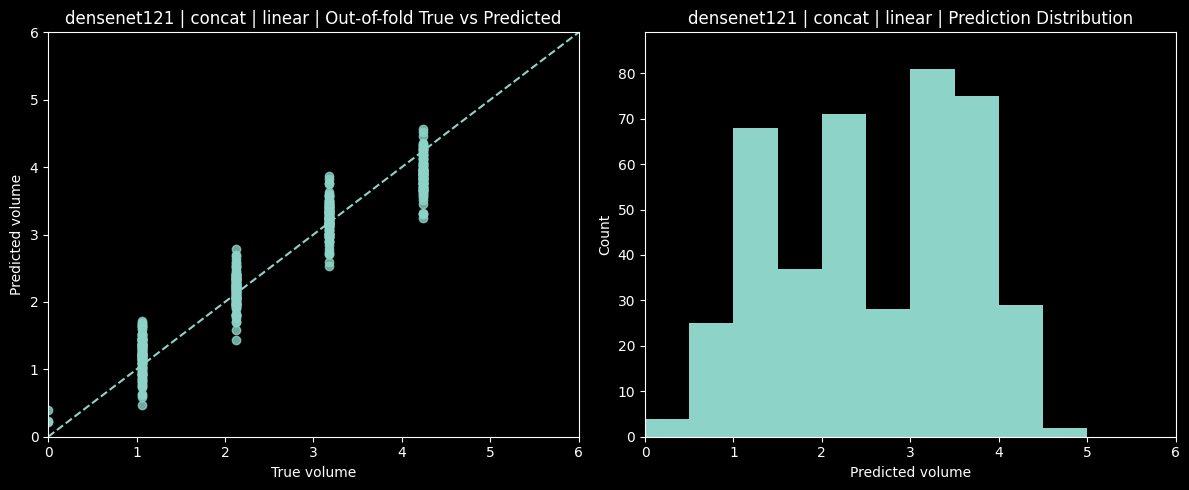

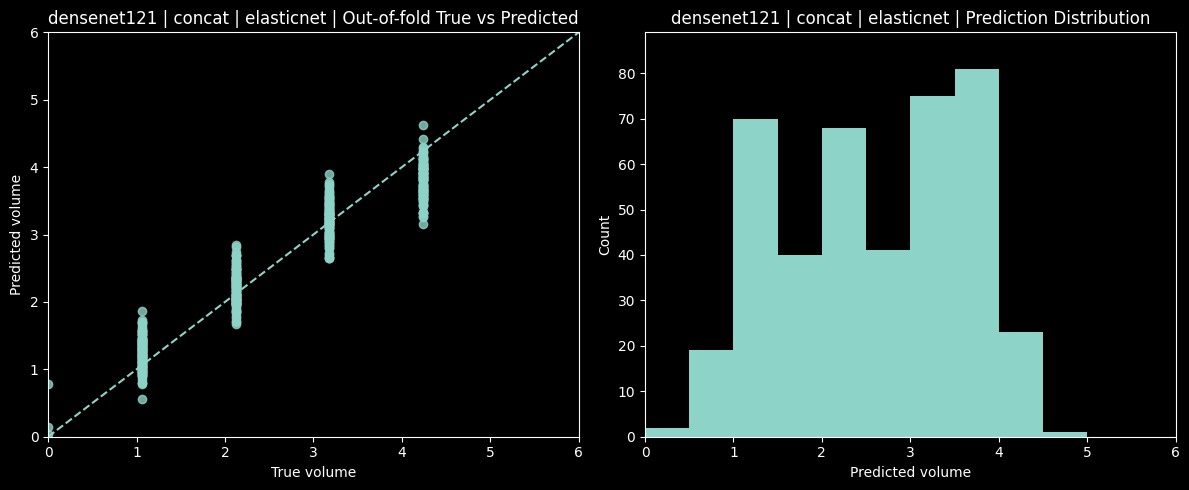

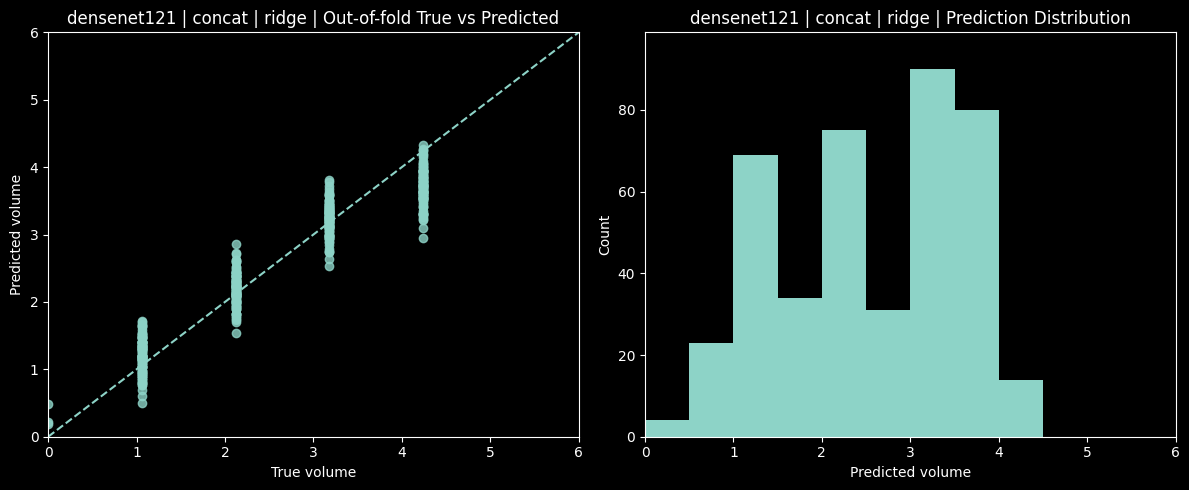

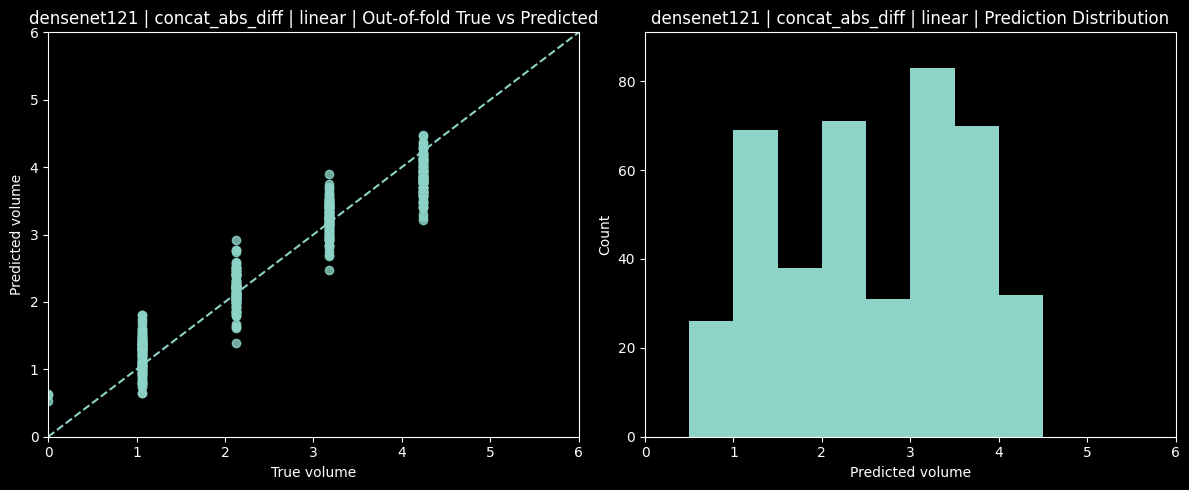

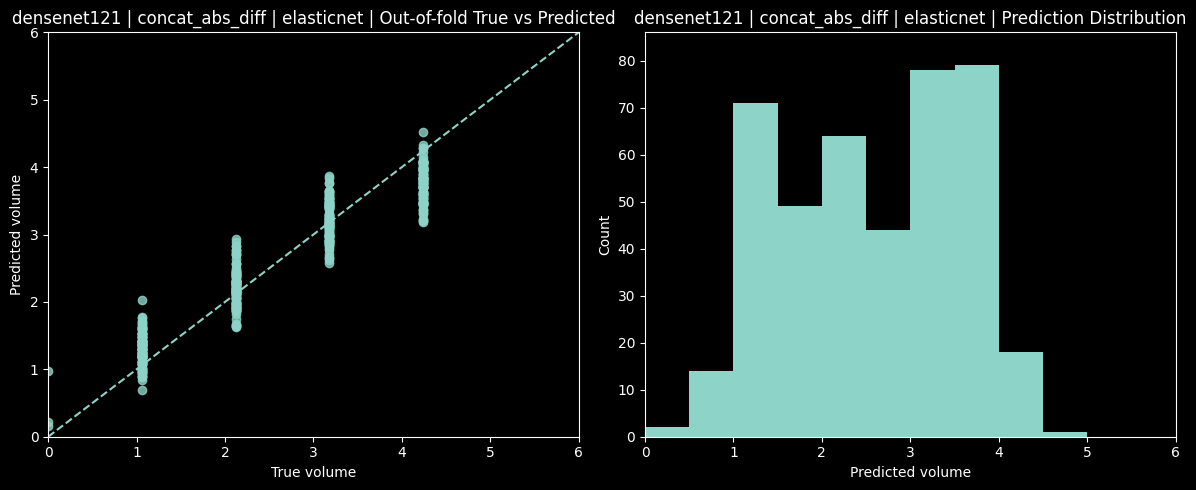

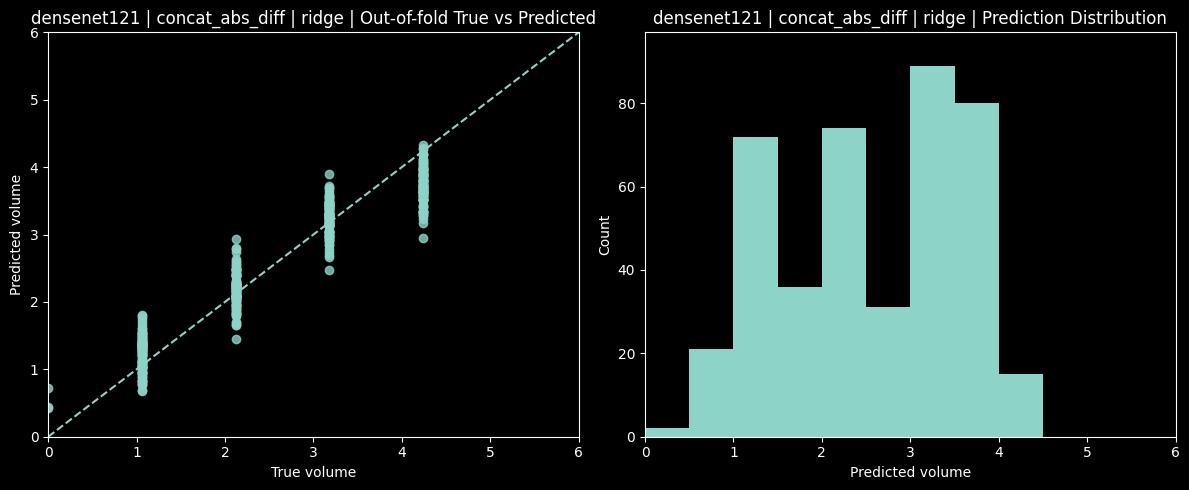

In [12]:
display(all_lovo_summary)

for _, row in all_lovo_summary.head(6).iterrows():
    key = (row["backbone"], row["fusion"])
    artifact = nested_artifacts[key]
    y_true = artifact["y"]
    y_pred = artifact["oof_predictions"][row["regressor"]]
    title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
    make_oof_plot(y_true, y_pred, title_prefix=title)

## Plot Predictions Per Withheld Volume

In [13]:
lovo_prediction_rows = []

for (backbone_name, fusion_name), model_dict in all_lovo_results.items():
    X_tmp, y_tmp, _ = build_feature_matrix(
        samples=samples,
        backbone_name=backbone_name,
        fusion_name=fusion_name,
        cache_dir=EMBEDDING_CACHE_DIR,
        device=DEVICE,
        top_mask_paths=TOP_ROI_MASKS,
        side_mask_paths=SIDE_ROI_MASKS
    )

    for model_name, folds in model_dict.items():
        y_pred = all_lovo_oof_predictions[(backbone_name, fusion_name)][model_name]

        for i in range(len(y_tmp)):
            lovo_prediction_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "model": model_name,
                "true_volume": y_tmp[i],
                "pred_volume": y_pred[i],
                "held_out_volume": y_tmp[i],
                "config": f"{backbone_name} | {fusion_name} | {model_name}",
            })

leave_one_volume_predictions = pd.DataFrame(lovo_prediction_rows)

densenet121 + concat_abs_diff: 100%|██████████| 420/420 [00:00<00:00, 3045.61it/s]


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,concat,linear,0.259574,0.060189,0.097078,0.042400,0.305256,0.062430,NaN,NaN
1,densenet121,concat,elasticnet,0.292117,0.083265,0.143534,0.076232,0.365925,0.098146,NaN,NaN
2,densenet121,concat,ridge,0.293463,0.122526,0.132897,0.108854,0.341635,0.127209,NaN,NaN
3,densenet121,concat_abs_diff,linear,0.333864,0.147499,0.161734,0.111094,0.380156,0.131207,NaN,NaN
4,densenet121,concat_abs_diff,elasticnet,0.336473,0.107366,0.185311,0.111491,0.411129,0.127606,NaN,NaN
5,densenet121,concat_abs_diff,ridge,0.345091,0.147914,0.174409,0.118538,0.393061,0.141111,NaN,NaN


Predicted volumes on the held-out sets, for each selected config:


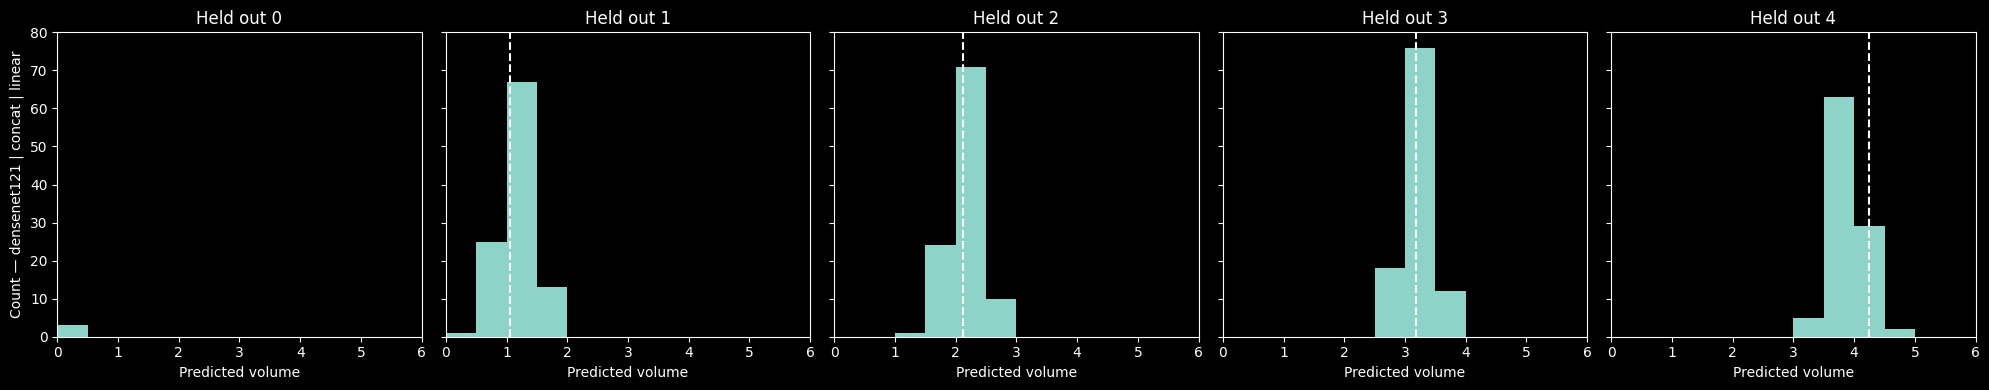

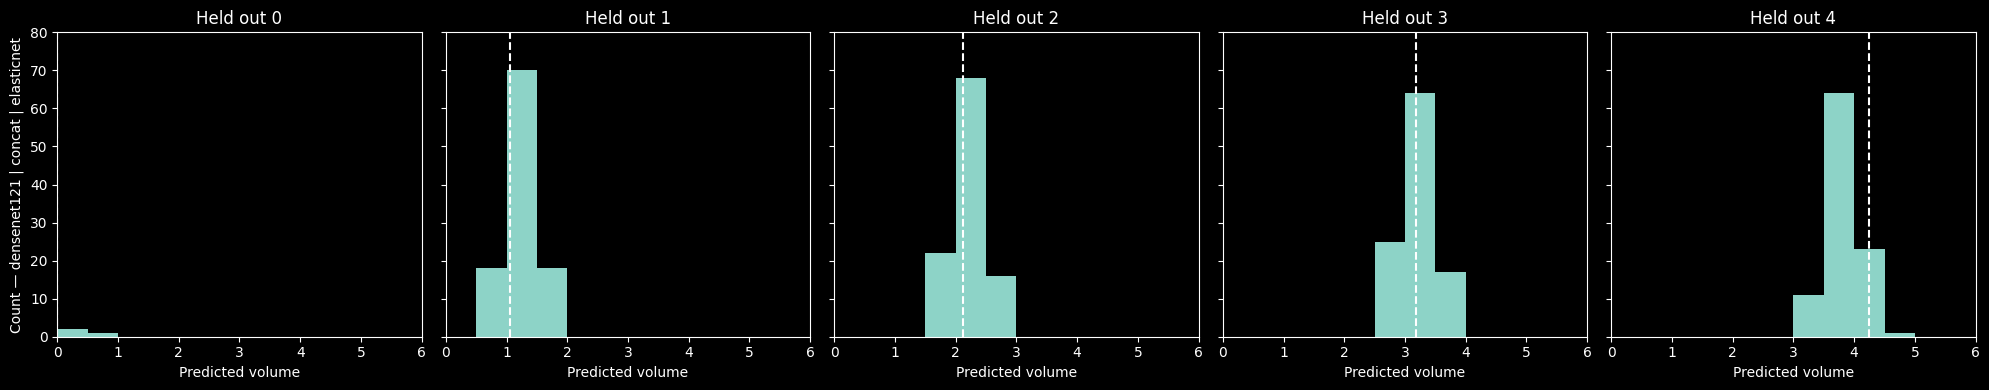

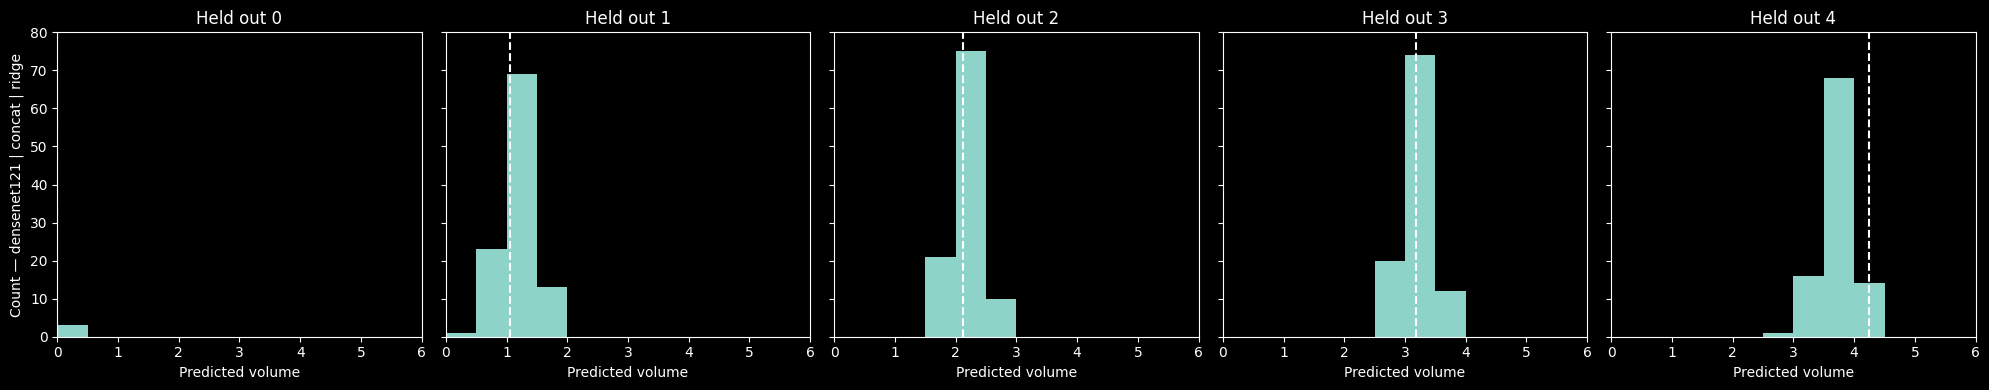

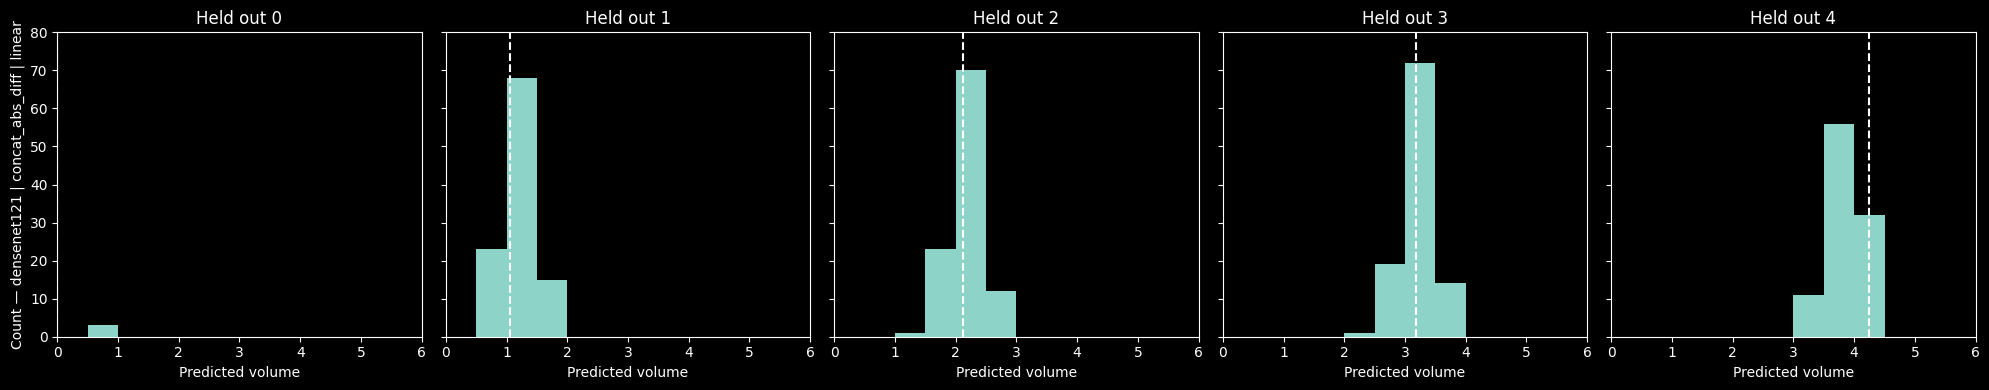

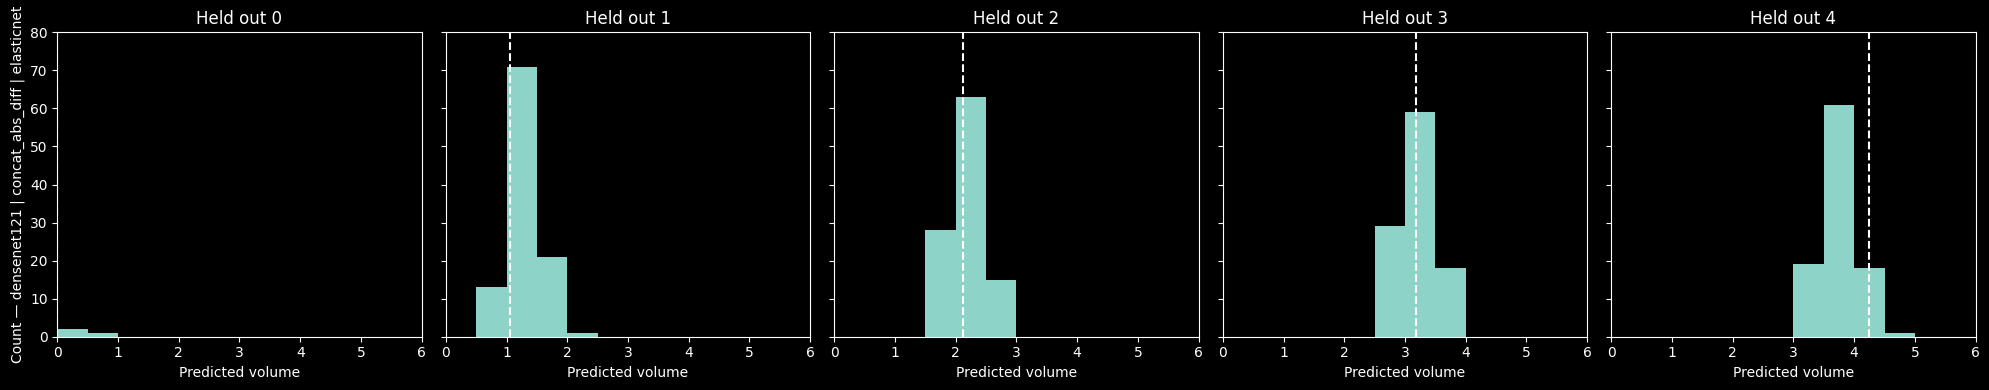

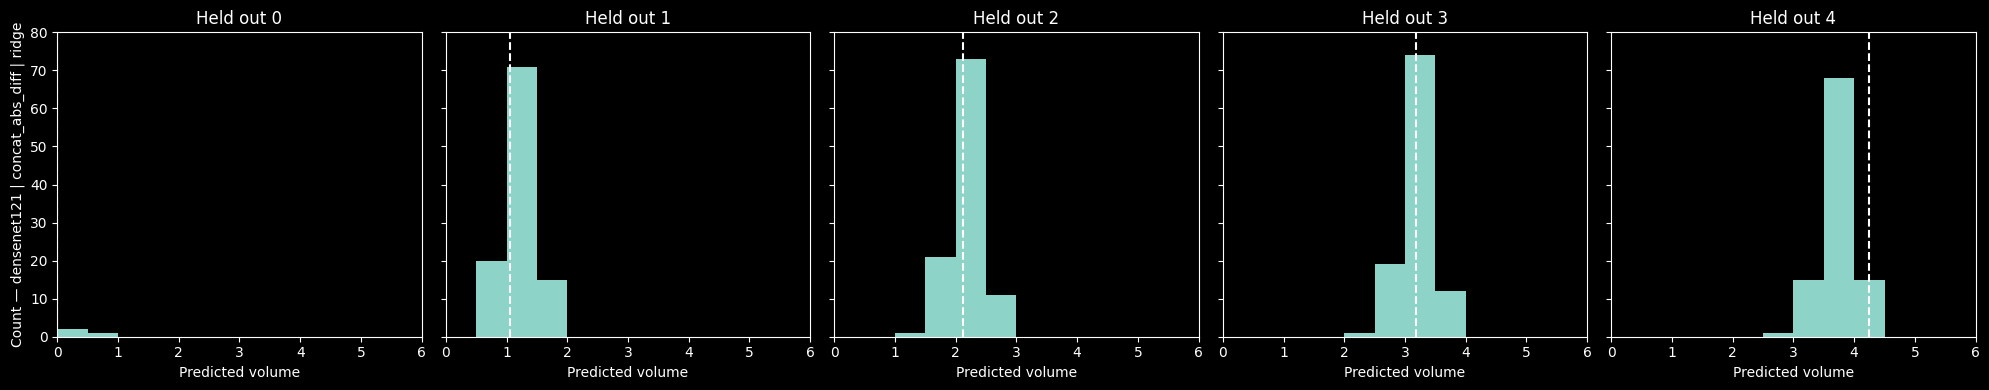

In [14]:
unique_volumes = np.sort(leave_one_volume_predictions["held_out_volume"].unique())

display(all_lovo_summary)
PLOT_CONFIGS = all_lovo_summary.head(6).apply(
    lambda row: f"{row['backbone']} | {row['fusion']} | {row['regressor']}",
    axis=1
).tolist()

print("Predicted volumes on the held-out sets, for each selected config:")

for config_name in PLOT_CONFIGS:
    predictions = leave_one_volume_predictions[
        leave_one_volume_predictions["config"] == config_name
    ].copy()

    fig, axes = plt.subplots(
        1, len(unique_volumes),
        figsize=(4 * len(unique_volumes), 4),
        sharey=True,
    )
    if len(unique_volumes) == 1:
        axes = [axes]

    for ax, vol in zip(axes, unique_volumes):
        subset = predictions[predictions["held_out_volume"] == vol]
        counts, _, _ = ax.hist(subset["pred_volume"], bins=12, range=(0, 6))
        hist_height = max(80, int(np.max(counts) * 1.1))
        ax.set_xlim(0, 6)
        ax.set_ylim(0, hist_height)
        ax.axvline(vol, linestyle="--")
        ax.set_title(f"Held out {int(vol)}")
        ax.set_xlabel("Predicted volume")

    axes[0].set_ylabel(f"Count — {config_name}")
    plt.tight_layout()
    plt.show()

## Show Per Volume Performance for All Configurations
Sorted by the mean MAE on the highest volume value (76), since that seems to be most problematic to predict when left out.

In [10]:
mae_per_volume_rows = []

for config_name, df_cfg in leave_one_volume_predictions.groupby("config"):
    backbone_name, fusion_name, model_name = config_name.split(" | ")

    for vol, df_vol in df_cfg.groupby("held_out_volume"):
        mae = np.mean(np.abs(df_vol["pred_volume"] - df_vol["true_volume"]))

        mae_per_volume_rows.append({
            "backbone": backbone_name,
            "fusion": fusion_name,
            "model": model_name,
            "held_out_volume": vol,
            "mae": mae,
        })

mae_per_volume_df = pd.DataFrame(mae_per_volume_rows)

mae_per_volume_wide = (
    mae_per_volume_df.pivot_table(
        index=["backbone", "fusion", "model"],
        columns="held_out_volume",
        values="mae",
        aggfunc="mean",
    )
    .reset_index()
)

mae_per_volume_wide.columns.name = None
mae_per_volume_wide = mae_per_volume_wide.rename(columns={
    0: "mae_mean_0",
    1.06: "mae_mean_1_06",
    2.12: "mae_mean_2_12",
    3.18: "mae_mean_3_18",
    4.24: "mae_mean_4_24",
})

display(mae_per_volume_wide.sort_values(["mae_mean_4_24"]))

,backbone,fusion,model,mae_mean_0,mae_mean_1_06,mae_mean_2_12,mae_mean_3_18,mae_mean_4_24
1,densenet121,concat,linear,0.285785,0.253572,0.200197,0.198231,0.360084
4,densenet121,concat_abs_diff,linear,0.593752,0.260373,0.207056,0.209251,0.398888
0,densenet121,concat,elasticnet,0.320205,0.251418,0.221909,0.224299,0.442755
3,densenet121,concat_abs_diff,elasticnet,0.453758,0.280633,0.234835,0.234860,0.478277
5,densenet121,concat_abs_diff,ridge,0.530724,0.259733,0.210508,0.205805,0.518682
2,densenet121,concat,ridge,0.290945,0.248040,0.203796,0.195705,0.528828


## Save results

In [16]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"top_side_frozen_lovo_{timestamp}.csv"
all_lovo_summary.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

hyperparams_name = f"top_side_frozen_lovo_best_hyperparameters_{timestamp}.json"

best_hyperparameters = {}
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    config_key = f"{backbone_name}__{fusion_name}"
    best_hyperparameters[config_key] = {}
    for regressor_name, folds in artifact["nested_results"].items():
        fold_params = [
            {
                "fold": f["fold"],
                "best_params": f["best_params"],
                "MAE": f.get("MAE"),
                "RMSE": f.get("RMSE"),
                "R2": f.get("R2"),
                "MSE": f.get("MSE"),
            }
            for f in folds
            if f.get("best_params")
        ]

        best_hyperparameters[config_key][regressor_name] = fold_params

with open(OUTPUT_DIR / hyperparams_name, "w") as f:
    json.dump(best_hyperparameters, f, indent=2, default=str)

print("Saved:", OUTPUT_DIR / hyperparams_name)

oof_rows = []
sample_meta = samples[["file_name", "exp_id", "volume", "top_path", "side_path"]].reset_index(drop=True)

for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    for regressor_name, y_pred in artifact["oof_predictions"].items():
        y_true = artifact["y"]
        for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
            oof_rows.append({
                "backbone": backbone_name,
                "fusion": fusion_name,
                "regressor": regressor_name,
                "sample_idx": i,
                "exp_id": sample_meta.loc[i, "exp_id"],
                "top_path": sample_meta.loc[i, "top_path"],
                "side_path": sample_meta.loc[i, "side_path"],
                "volume": sample_meta.loc[i, "volume"],
                "y_true": float(yt),
                "y_pred": float(yp),
                "residual": float(yp - yt),
                "abs_error": float(abs(yp - yt)),
            })

oof_df = pd.DataFrame(oof_rows)
oof_name = f"top_side_frozen_lovo_oof_predictions_{timestamp}.csv"
oof_df.to_csv(OUTPUT_DIR / oof_name, index=False)

print("Saved:", OUTPUT_DIR / oof_name)

Saved: results/top_side_frozen_lovo_2026-04-02_01-09-20.csv
Saved: results/top_side_frozen_lovo_best_hyperparameters_2026-04-02_01-09-20.json
Saved: results/top_side_frozen_lovo_oof_predictions_2026-04-02_01-09-20.csv
